In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext
from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

In [2]:
# --- import data: bottleneck computed in 2 ways---
abel24 = pd.read_csv('Abel_Nb_24hpi.csv')
abel48 = pd.read_csv('Abel-Nb_48hpi.csv')
leo24  = pd.read_csv('Leonard_Nb_24hpi.csv')
leo48  = pd.read_csv('Leonard_Nb_48hpi.csv')

In [3]:
# --- helper: sort labels like #1..#11 then #1+dox.. ---
def label_sort_key(lbl):
    m = re.match(r"#\s*(\d+)\s*(\+dox)?", str(lbl))
    if not m:
        return (2, float("inf"), str(lbl))
    num = int(m.group(1))
    dox = 1 if m.group(2) else 0   # noDox first, then +dox
    return (dox, num, str(lbl))

### Comparison at 24 hpi

In [4]:
# --- Figure 1 data (24 hpi): Abel Nb vs Leonard Nb (use Leonard lung; blood is NaN at 24h) ---
leo24_24 = leo24[leo24["hpi"] == 24].copy() if "hpi" in leo24.columns else leo24.copy()

df24 = (abel24.rename(columns={"Nb_bottleneck_size": "Abel_Nb"})[["label", "Abel_Nb"]].merge(
        leo24_24.rename(columns={"lung": "Leonard_Nb"})[["label", "Leonard_Nb"]], on="label", how="inner"))

df24["sortkey"] = df24["label"].map(label_sort_key)
df24 = df24.sort_values("sortkey").drop(columns="sortkey").reset_index(drop=True)

# export merged 24h comparison table
#df24.to_csv("compare_24hpi_Abel_vs_Leonard.csv", index=False)

In [5]:
#define separate scales in one y-axis
def forward(y):
    y = np.asarray(y, dtype=float)
    y = np.clip(y, 1e-12, None)  # avoid log(0)
    t = np.empty_like(y)

    mA = y <= y1                 # below 1e3: linear (separates 0.5e3 and 1e3)
    t[mA] = alpha * y[mA]

    mB = (y > y1) & (y <= y2)    # 1e3..2e4: compressed log
    t[mB] = compress * np.log10(y[mB])

    mC = y > y2                  # above 2e4: normal log slope (but continuous)
    high_scale = 2.0   # >1 stretches the region above 20*10^3 (try 1.5–3.0)
    t[mC] = t2 + high_scale * (np.log10(y[mC]) - logy2)

    return t

def inverse(t):
    t = np.asarray(t, dtype=float)
    y = np.empty_like(t)

    mA = t <= t1
    y[mA] = t[mA] / alpha

    mB = (t > t1) & (t <= t2)
    y[mB] = 10 ** (t[mB] / compress)

    mC = t > t2
    y[mC] = 10 ** (logy2 + (t[mC] - t2))

    return y

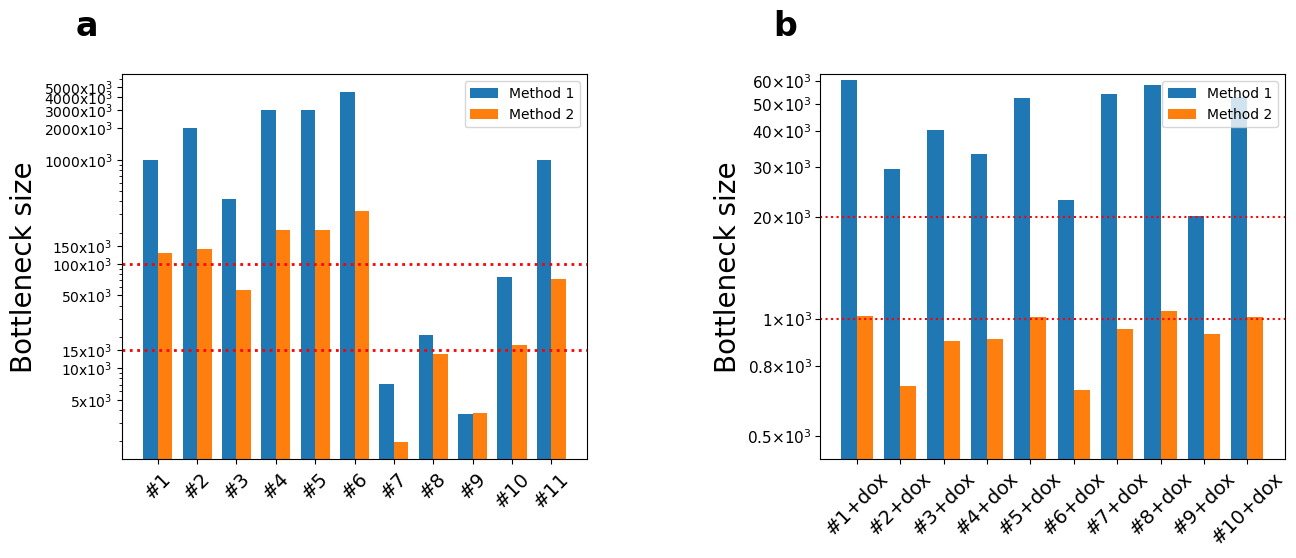

In [6]:
# ========== FIGURE 1: 24 hpi (2 subfigures: a) no-dox, b) +dox) using a loop ==========
groups = [ ("1a) no-dox (24 hpi)", df24[~df24["label"].astype(str).str.contains(r"\+dox", regex=True)]),
           ("1b) +dox (24 hpi)",   df24[df24["label"].astype(str).str.contains(r"\+dox",  regex=True)]),]

w = 0.5
gap = 1.35
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
plt.subplots_adjust(wspace = 0.5)

label = np.array(['a', 'b'])
for i in range (0, 2):
    axes[i].text(-.1, 1.1, '{}'.format(label[i]), transform=axes[i].transAxes, size = 24, weight='bold')

for ax, (title, subdf) in zip(axes, groups):
    subdf = subdf.copy()
    x = np.arange(len(subdf))*gap
    ax.bar(x - w/2, subdf["Abel_Nb"].to_numpy(),    width=w, label = "Method 1")
    ax.bar(x + w/2, subdf["Leonard_Nb"].to_numpy(), width=w, label = "Method 2")
    ax.set_xticks(x)
    ax.set_xticklabels(subdf["label"].tolist(), fontsize = 14, rotation = 45)
    #ax.set_title(title)
    ax.legend()
    ax.set_ylabel("Bottleneck size", fontsize = 20)

# Adjust y-axis Figure a
axes[0].axhline(1.5e4, color="red", linestyle=":", linewidth=2)
axes[0].axhline(1e5, color="red", linestyle=":", linewidth=2)
axes[0].set_yscale("log")
yticks0 = [5e3, 1e4, 1.5e4, 5e4, 1e5, 1.5e5, 1e6, 2e6, 3e6, 4e6, 5e6]
axes[0].set_yticks(yticks0, [f"{int(t/1000)}x10$^3$" for t in yticks0])

# Adjust y-axis Figure b
axes[1].axhline(1e3, color="red", linestyle=":", linewidth=1.5)
axes[1].axhline(20e3, color="red", linestyle=":", linewidth=1.5)

y1 = 1e3                  # 10^3 breakpoint
y2 = 2e4                  # 20*10^3 breakpoint
compress = 0.55           # <1 compresses (10^3 -> 2*10^4); try 0.4–0.8
# continuity constants
t1 = compress * np.log10(y1)
alpha = t1 / y1
logy2 = np.log10(y2)
t2 = compress * logy2

axes[1].set_yscale("function", functions=(forward, inverse))

yticks1 = [0.5e3, 0.8e3, 1e3, 2e4, 3e4, 4e4, 5e4, 6e4]
#axes[1].set_yscale("log")
axes[1].set_yticks(yticks1)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y/1e3:g}×10$^3$"))
axes[1].tick_params(axis="y", labelsize=11, pad=2)
ax.set_ylim(4e2, ax.get_ylim()[1])

plt.show()

### Comparison at 48 hpi

In [7]:
leo48_48 = leo48[leo48["hpi"] == 48].copy() if "hpi" in leo48.columns else leo48.copy()

df48 = (abel48[["label", "lung", "blood"]].rename(columns={"lung": "Abel_lung", "blood": "Abel_blood"})
        .merge(leo48_48[["label", "lung", "blood"]].rename(columns={"lung": "Leonard_lung", "blood": "Leonard_blood"}),
        on="label", how="inner"))
df48["sortkey"] = df48["label"].map(label_sort_key)
df48 = df48.sort_values("sortkey").drop(columns="sortkey").reset_index(drop=True)

df48_clean = df48.copy()
df48_clean["label"] = df48_clean["label"].astype(str).str.strip()

# ---------- helpers ----------
def is_dox_label(lbl):
    return "+dox" in str(lbl)

df_nodox = df48_clean[~df48_clean["label"].apply(is_dox_label)].reset_index(drop=True)
df_dox   = df48_clean[ df48_clean["label"].apply(is_dox_label)].reset_index(drop=True)
# export merged 48h comparison table
#df48.to_csv("compare_48hpi_Abel_vs_Leonard_lung_blood.csv", index=False)

In [8]:
ABEL_C    = "C0"   # default blue
LEONARD_C = "C1"   # default orange
H_BLOOD = "///" # Tissue pattern

# Abel vs Leonard styling bars
def bar_style(method, tissue):
    # Method controls color; Tissue controls hatch
    color = ABEL_C if method == "Abel" else LEONARD_C
    hatch = H_BLOOD if tissue == "blood" else None
    return dict(facecolor=color, edgecolor="black", hatch=hatch, linewidth=0.8)

In [9]:
#plot function
def plot_group(ax_main, ax_side, sub, title, move_label=None, main_cap=None):
    sub = sub.copy()

    # split out the forced side label (e.g. #12)
    side = None
    if move_label is not None:
        hit = sub.loc[sub["label"].astype(str).str.strip() == move_label]
        if not hit.empty:
            side = hit.copy()
            sub = sub.drop(hit.index).copy()

    # x positions with extra spacing between mouse clusters
    n = len(sub)
    cluster_gap = 0.25
    w = 0.25
    step = 4*w + cluster_gap
    x = np.arange(n)*step

    # offsets (4 bars per mouse)
    offs = {("Abel","lung"):   -1.5*w, ("Leonard","lung"):-0.5*w, ("Abel","blood"):   0.5*w, ("Leonard","blood"):1.5*w,}

    # plot main
    for (method,tissue), dx in offs.items():
        col = f"{method}_{tissue}"
        ax_main.bar(x + dx, sub[col].to_numpy(), width=w, **bar_style(method,tissue))

    ax_main.set_xticks(x)
    ax_main.set_xticklabels(sub["label"].tolist(), fontsize = 18, rotation=45, ha="right")
    ax_main.set_ylabel("Bottleneck Size", fontsize = 18)

    # main scaling: separate per panel
    max_main = float(np.nanmax(sub[["Abel_lung","Leonard_lung","Abel_blood","Leonard_blood"]].to_numpy()))
    if main_cap is None:
        main_cap = max(1.0, max_main * 1.15)
    ax_main.set_ylim(0, main_cap)
    
    # --- add stars for missing data (NaN) in the MAIN panel ---
    cols4 = ["Abel_lung","Leonard_lung","Abel_blood","Leonard_blood"]
    A = sub[cols4].to_numpy(dtype=float)              # keeps NaNs
    cluster_max = np.nanmax(A, axis=1)                # max per mouse (ignoring NaN)

    ymin, ymax = ax_main.get_ylim()
    offset = 0.03 * (ymax - ymin)                     # tweak 0.02–0.06

    for i in range(len(sub)): # if all 4 are NaN, cluster_max[i] will be NaN -> treat as 0
        base = cluster_max[i] if np.isfinite(cluster_max[i]) else 0.0
        y_star = 3

        # put star ABOVE the *missing* bar(s), centered on that bar (not on bar edge)
        for (method, tissue), dx in offs.items():
            col = f"{method}_{tissue}"
            if pd.isna(sub.iloc[i][col]):
                x_star = x[i] + dx
                ax_main.text(x_star, y_star, "*", ha="center", va="bottom", fontsize=14, zorder=10)

    # side panel
    if ax_side is None:
        return

    if side is None or side.empty:
        ax_side.axis("off")
        return

    xs = np.array([0.0])     # single cluster on side
    for (method, tissue), dx in offs.items():
        col = f"{method}_{tissue}"
        ax_side.bar(xs + dx, side[col].to_numpy(), width=w, **bar_style(method, tissue))
    
    ax_side.set_xticks(xs)
    ax_side.set_xticklabels(side["label"].tolist(), fontsize = 18, rotation=45, ha ="right")
    max_side = float(np.nanmax(side[["Abel_lung","Leonard_lung","Abel_blood","Leonard_blood"]].to_numpy()))
    ax_side.set_ylim(0, max_side * 1.10)

    # cleaner look like your example
    ax_side.yaxis.tick_right()
    ax_side.tick_params(labelleft=False)
    ax_main.spines["right"].set_visible(False)
    ax_side.spines["left"].set_visible(False)

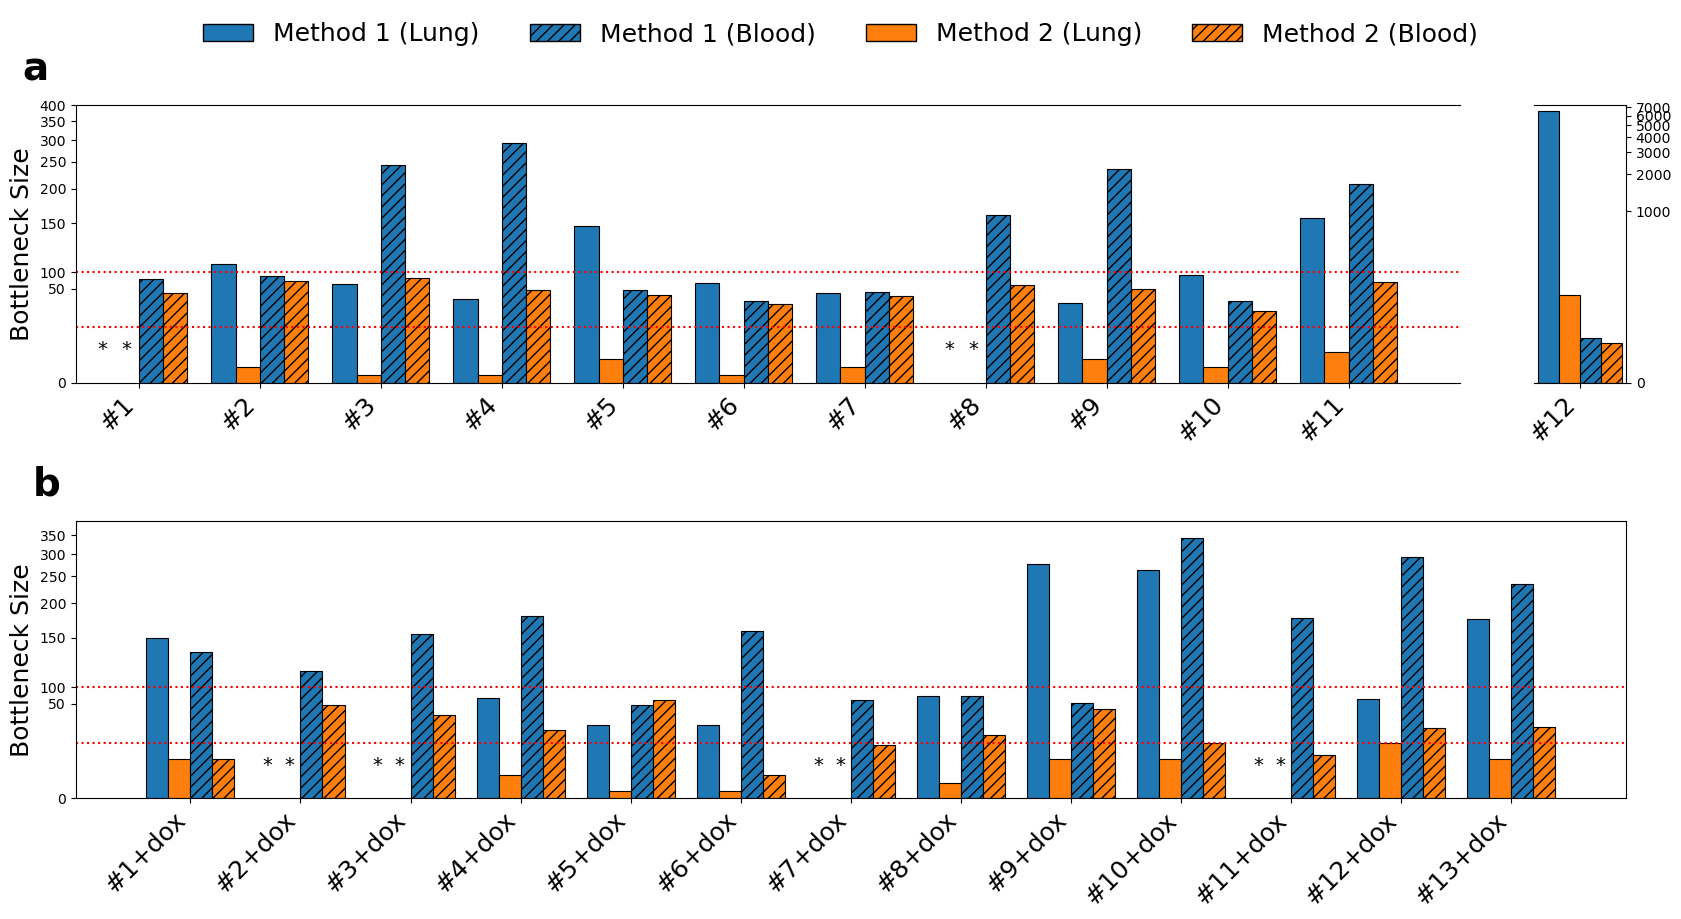

In [10]:
# ---------- FIGURE 2: (a) no-dox with #12 on side; (b) +dox separate scaling ----------
fig = plt.figure(figsize=(20, 9))
gs = GridSpec(2, 2, width_ratios=[12, 0.8], hspace=0.5, wspace=0.1)

ax_a_main = fig.add_subplot(gs[0,0])
ax_a_side = fig.add_subplot(gs[0,1]) # (a) no-dox: force #12 to side panel; main capped like your example
plot_group(ax_a_main, ax_a_side, df_nodox, "2a) 48 hpi — no dox", move_label="#12", main_cap=400)

ax_b_main = fig.add_subplot(gs[1, :])     # <-- spans full width (b) +dox: separate scaling 
ax_b_side = None                          # no side axis
plot_group(ax_b_main, ax_b_side, df_dox, "2b) 48 hpi — +dox", move_label=None, main_cap=None)

# legend (tissue + method): build custom legend handles once
handles = [mpatches.Patch(facecolor=ABEL_C, edgecolor="black", label = "Method 1 (Lung)"),
           mpatches.Patch(facecolor=ABEL_C, edgecolor="black", hatch=H_BLOOD, label="Method 1 (Blood)"),
           mpatches.Patch(facecolor=LEONARD_C, edgecolor="black", label="Method 2 (Lung)"),
           mpatches.Patch(facecolor=LEONARD_C, edgecolor="black", hatch=H_BLOOD, label="Method 2 (Blood)"),]
fig.legend(handles=handles, loc="upper center", fontsize = 18, ncol=4, frameon=False)

#scale customize
y1 = 5                 # 5 breakpoint
y2 = 100                  # 100 breakpoint
compress = 0.4           # <1 compresses (5 -> 100); try 0.4–0.8
# continuity constants
t1 = compress * np.log10(y1)
alpha = t1 / y1
logy2 = np.log10(y2)
t2 = compress * logy2

ax_a_main.set_yscale("function", functions=(forward, inverse))
ax_a_side.set_yscale("function", functions=(forward, inverse))
ax_b_main.set_yscale("function", functions=(forward, inverse))

ax_a_main.axhline(10, color="red", linestyle=":", linewidth=1.5)
ax_a_main.axhline(100, color="red", linestyle=":", linewidth=1.5)
ax_b_main.axhline(10, color="red", linestyle=":", linewidth=1.5)
ax_b_main.axhline(100, color="red", linestyle=":", linewidth=1.5)

ax_a_main.text(-0.02, 1.2, "a", transform=ax_a_main.transAxes, fontsize=28, fontweight="bold", va="top", ha="right")
ax_b_main.text(-0.01, 1.2, "b", transform=ax_b_main.transAxes, fontsize=28, fontweight="bold", va="top", ha="right")
plt.show()